In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist

In [3]:
keras.__version__

'3.10.0'

In [4]:
tf.__version__

'2.19.0'

In [5]:
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [7]:
y_train.shape, y_test.shape

((60000,), (10000,))

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10000, random_state=42)

In [10]:
X_train.shape, X_test.shape, X_val.shape

((50000, 28, 28), (10000, 28, 28), (10000, 28, 28))

## EDA

In [11]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  32,  37,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  88, 112,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,
          2,   2,   0,   0,   0,   0,   0,   0,   0,   7, 119,  72,  56,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,
          0,   0,   0,   0,   2,  21,  25,  32,  21, 135,  60,   0, 140,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          9,  39,  58,  65,  81,  60,  95,  44, 102, 140,  32,   2, 138,
         23,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        102, 126,  65,  21,  25,  23,  30,   0,  77, 161,   0, 100, 149,
         23,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   0,   7,
        140, 105,  93, 126, 131, 168, 231, 173,  88, 182, 119,   2,  28,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         98, 131, 203, 135,  35,  25,   0, 133, 131,  95,  95,  18,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         63, 152,  16,   0,   0,   0,   0,   2,  53,  60,  70, 100,  30,
          0,   2],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  25,
         84,   0,   0,   2,   0,   0,   0,  32,  37,  25,  72,  37, 128,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,  74,
          9,   0,   0,   0,   0,   0,   2,  67,  21,  44,   9,   0,  51,
         93,  11],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   0,  44,
         79,   0,   0,   0,   0,   0,  42,  58,  42,  65,  21,   0,   0,
         95,  51],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         88,  60,   0,   0,   0,   0,  67,  25,  28,  46,   0,   0,  39,
        159,  11],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  67,  70,   2,   0,   0,  44,  21,  21,  67,  81,  88, 149,
        128,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  67, 112,  23,  32,  49,  58,  46,  60, 163, 105, 102,
        112,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  18,  81,  51,  28,
         30,  11,  11,  65,  60,  88,  60,  35, 102, 191, 114, 180, 102,
         86,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  74,  65,  53,  49,
         53,  42,  44,  39,  72,  74,  16, 123, 187,  16,   0, 166, 128,
         49,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  88,  16,   0,   0,
          0,   0,   7,   0,  91,  39, 116, 182,   0,   0,   0, 131, 116,
         37,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  56, 198, 156,   0,
          0,   0,   0,  16,  70,  53, 182,   0,   0,   0,   0,  86, 116,
         30,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  28,  63, 149, 133,
          4,   0,   0, 119, 140, 145,   7,   0,   4,   2,   0,  70, 116,
         18,   0],
       [  0,   0,   0,   0,   0,   0,  14,  42,  46,  39,  23,  21, 119,
        105,   0,  60,  98, 170,  11,   0,   0,   2,   4,   0,  74, 116,
         14,   0],
       [  2,   0,   0,   0,   2, 100,  84,  77, 184, 236,  88,  21,  30,
         77, 116,  63, 138, 147,   0,   0,   0,   0,   2,   0,  63, 107,
          4,   0],
       [  0,   0,   0,   0,   4, 109,  63,   4,   7, 100,  56,  18,  25,
         35,  74, 114, 119,   0,   0,   0,   0,   0,   4,   0,  60, 105,
          2,   0],
       [  2,  21,  84, 126,  25,  30, 198,  23,   4,  11,  23,  42,  39,
         28,   7, 233,  21,   0,   0,   0,   0,   0,   2,   0,  63, 107,
          0,   0],
       [114, 138,  70,  49,  39,  23, 21

In [12]:
class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
             "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

In [13]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  32,  37,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  88, 112,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,
          2,   2,   0,   0,   0,   0,   0,   0,   0,   7, 119,  72,  56,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,
          0,   0,   0,   0,   2,  21,  25,  32,  21, 135,  60,   0, 140,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          9,  39,  58,  65,  81,  60,  95,  44, 102, 140,  32,   2, 138,
         23,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        102, 126,  65,  21,  25,  23,  30,   0,  77, 161,   0, 100, 149,
         23,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   0,   7,
        140, 105,  93, 126, 131, 168, 231, 173,  88, 182, 119,   2,  28,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         98, 131, 203, 135,  35,  25,   0, 133, 131,  95,  95,  18,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         63, 152,  16,   0,   0,   0,   0,   2,  53,  60,  70, 100,  30,
          0,   2],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  25,
         84,   0,   0,   2,   0,   0,   0,  32,  37,  25,  72,  37, 128,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,  74,
          9,   0,   0,   0,   0,   0,   2,  67,  21,  44,   9,   0,  51,
         93,  11],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   0,  44,
         79,   0,   0,   0,   0,   0,  42,  58,  42,  65,  21,   0,   0,
         95,  51],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         88,  60,   0,   0,   0,   0,  67,  25,  28,  46,   0,   0,  39,
        159,  11],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  67,  70,   2,   0,   0,  44,  21,  21,  67,  81,  88, 149,
        128,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  67, 112,  23,  32,  49,  58,  46,  60, 163, 105, 102,
        112,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  18,  81,  51,  28,
         30,  11,  11,  65,  60,  88,  60,  35, 102, 191, 114, 180, 102,
         86,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  74,  65,  53,  49,
         53,  42,  44,  39,  72,  74,  16, 123, 187,  16,   0, 166, 128,
         49,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  88,  16,   0,   0,
          0,   0,   7,   0,  91,  39, 116, 182,   0,   0,   0, 131, 116,
         37,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  56, 198, 156,   0,
          0,   0,   0,  16,  70,  53, 182,   0,   0,   0,   0,  86, 116,
         30,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  28,  63, 149, 133,
          4,   0,   0, 119, 140, 145,   7,   0,   4,   2,   0,  70, 116,
         18,   0],
       [  0,   0,   0,   0,   0,   0,  14,  42,  46,  39,  23,  21, 119,
        105,   0,  60,  98, 170,  11,   0,   0,   2,   4,   0,  74, 116,
         14,   0],
       [  2,   0,   0,   0,   2, 100,  84,  77, 184, 236,  88,  21,  30,
         77, 116,  63, 138, 147,   0,   0,   0,   0,   2,   0,  63, 107,
          4,   0],
       [  0,   0,   0,   0,   4, 109,  63,   4,   7, 100,  56,  18,  25,
         35,  74, 114, 119,   0,   0,   0,   0,   0,   4,   0,  60, 105,
          2,   0],
       [  2,  21,  84, 126,  25,  30, 198,  23,   4,  11,  23,  42,  39,
         28,   7, 233,  21,   0,   0,   0,   0,   0,   2,   0,  63, 107,
          0,   0],
       [114, 138,  70,  49,  39,  23, 21

In [14]:
y_train[0]

np.uint8(5)

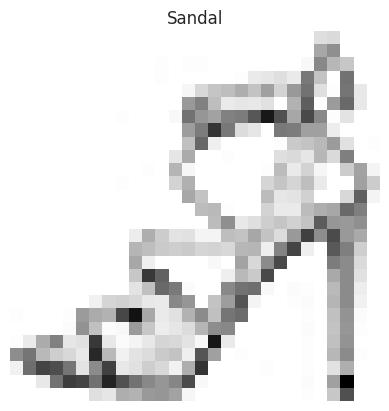

In [15]:
plt.imshow (X_train[0], cmap="binary")
plt.title (class_names[y_train[0]])
plt.axis("off")
plt.show()

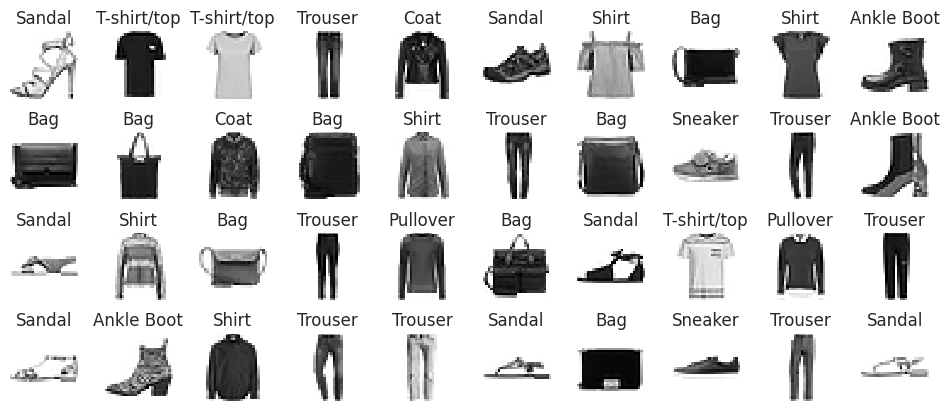

In [16]:
n_rows=4
n_cols=10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range (n_rows):
  for col in range(n_cols):
    index=n_cols * row + col
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
    plt.axis("off")
    plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [17]:
# Feature Scaling basically Normalizing
X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0

In [18]:
150/255

0.5882352941176471

## *Sequential Model DNN*

In [19]:
tf.keras.backend.clear_session() # free up memory
np.random.seed (42)
tf.random.set_seed(42)

In [ ]:
# Task: Play with the below hyperparameters;
# 1. Hidden Layer: (3, 5, 7)
# 2. Neuron per Layers:
# 3. Batch Size: (16, 32, 64)
# 4. Learning Rate: (le-5, le-3, le-1)
# 5. Optimiser: (SGB, RMSporp, ADAM)
# 6. Epochs: (10, 5, 6)
# Which configuration is giving higher validation accuracy.

In [21]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=X_train.shape[1:], name = "Input_Layer"),
    keras.layers.Dense(300, activation="relu", name="Hidden_Layer_1"),
    keras.layers.Dense(100, activation="relu", name="Hidden_Layer_2"),
    keras.layers.Dense(10, activation="softmax", name="Output_Layer") # softmax for multi-classification
 ])

In [22]:
# Before Training
weights, biases=model.layers[1].get_weights()

In [23]:
weights

array([[-0.07129138,  0.02395911, -0.03568171, ...,  0.00557112,
        -0.00311757, -0.03653157],
       [ 0.04228272, -0.02110932,  0.01838298, ...,  0.06202097,
         0.00157493, -0.07352046],
       [ 0.06046678,  0.06478533, -0.05020396, ..., -0.04004312,
         0.05880572,  0.05355725],
       ...,
       [ 0.02934306,  0.01939055, -0.03858019, ...,  0.01145723,
        -0.03167905,  0.03096192],
       [ 0.00173879,  0.00480832,  0.07019754, ...,  0.03091761,
         0.02348354,  0.06106685],
       [-0.04367274, -0.01710839, -0.05694869, ...,  0.0544012 ,
         0.0519309 ,  0.01597175]], dtype=float32)

In [24]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [26]:
weights.shape, biases.shape

((784, 300), (300,))

In [45]:
# Multi-classification
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [48]:
# Optional
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [30]:
history=model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6676 - loss: 1.0277 - val_accuracy: 0.8007 - val_loss: 0.5852
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8264 - loss: 0.5012 - val_accuracy: 0.8228 - val_loss: 0.5146
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8428 - loss: 0.4482 - val_accuracy: 0.8347 - val_loss: 0.4744
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8514 - loss: 0.4191 - val_accuracy: 0.8446 - val_loss: 0.4456
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8583 - loss: 0.3983 - val_accuracy: 0.8522 - val_loss: 0.4274
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8639 - loss: 0.3822 - val_accuracy: 0.8578 - val_loss: 0.4127
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8688 - loss: 0.3690 - val_accuracy: 0.8596 - val_loss: 0.4022
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8732 - loss: 0.3574 -

In [49]:
# Optional
history=model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_val, y_val))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8893 - loss: 0.3105 - val_accuracy: 0.8772 - val_loss: 0.3475
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8895 - loss: 0.3099 - val_accuracy: 0.8770 - val_loss: 0.3472
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8898 - loss: 0.3093 - val_accuracy: 0.8770 - val_loss: 0.3468
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8899 - loss: 0.3087 - val_accuracy: 0.8772 - val_loss: 0.3464
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8902 - loss: 0.3082 - val_accuracy: 0.8774 - val_loss: 0.3461


In [42]:
# Batch size should be Power of 2.
float(50000/32)

1562.5

In [43]:
1562.5*32

50000.0

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,612 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [32]:
from tensorflow.keras.utils import plot_model


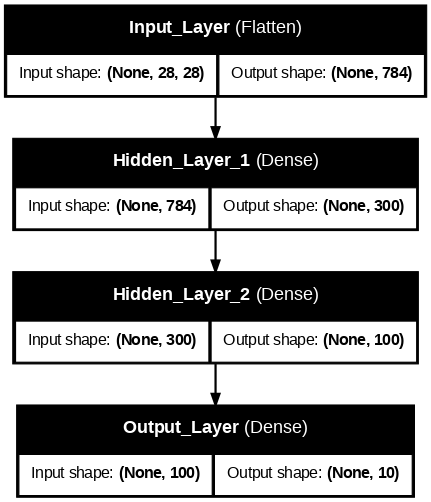

In [33]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True, dpi=80)

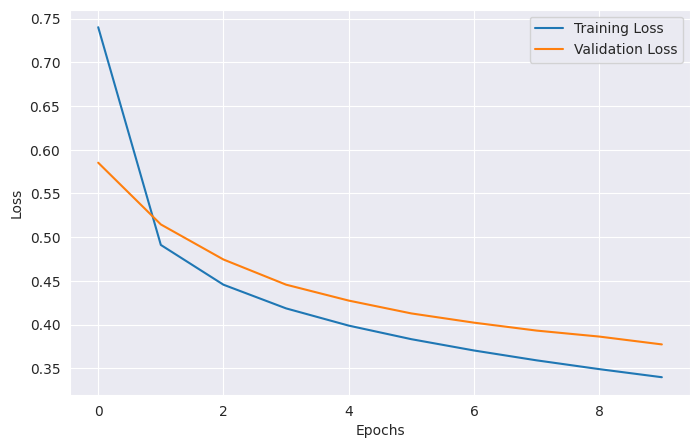

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

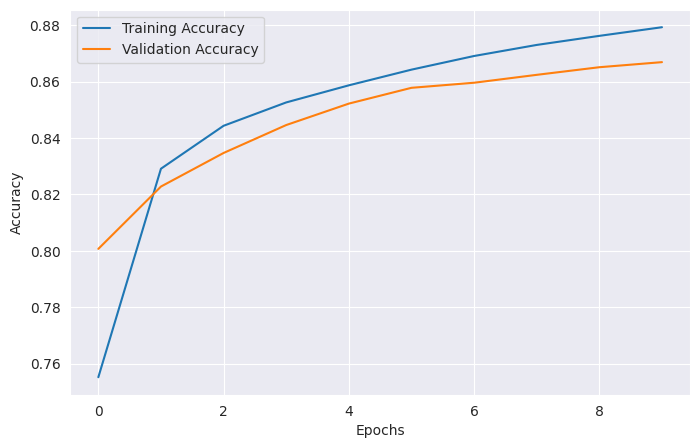

In [39]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [52]:
# Testing the model on Testing dataset
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.2f}")
print(f"Test Accuracy: {accuracy*100:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8730 - loss: 0.3661
Test Loss: 0.37
Test Accuracy: 86.96


In [53]:
X_new = X_test[:3]

In [54]:
y_prob = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [55]:
y_prob.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.07, 0.  , 0.08, 0.  , 0.84],
       [0.  , 0.  , 0.98, 0.  , 0.01, 0.  , 0.01, 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [56]:
y_pred=np.argmax(y_prob, axis=1)
y_pred

array([9, 2, 1])

In [57]:
np.array(class_names)[y_pred]

array(['Ankle Boot', 'Pullover', 'Trouser'], dtype='<U11')

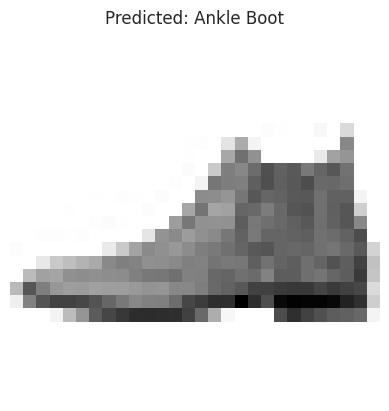

In [58]:
plt.imshow(X_new[0], cmap="binary")
plt.title(f"Predicted: {class_names[y_pred[0]]}")
plt.axis("off")
plt.show()

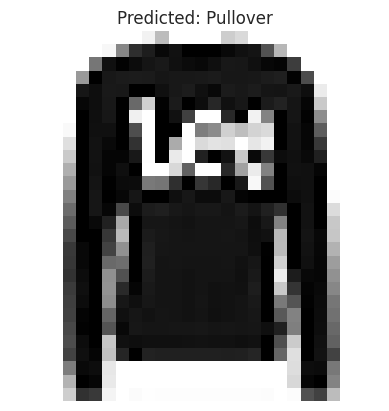

In [60]:
plt.imshow(X_new[1], cmap="binary")
plt.title(f"Predicted: {class_names[y_pred[1]]}")
plt.axis("off")
plt.show()

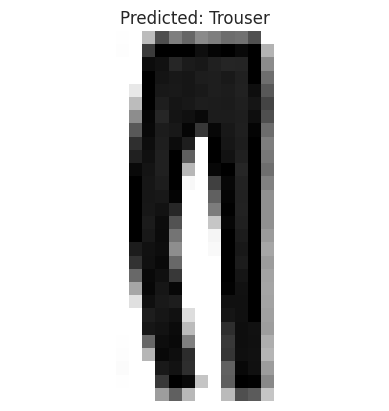

In [61]:
plt.imshow(X_new[2], cmap="binary")
plt.title(f"Predicted: {class_names[y_pred[2]]}")
plt.axis("off")
plt.show()